In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys, torch, matplotlib
from sbi.utils import MultipleIndependent
from torch.distributions import Uniform
from torch import nn
from sbi import utils as utils
from sbi.analysis import pairplot
from sbi.inference import NPE
import scipy.stats as st
import os, pickle
from matplotlib.gridspec import GridSpec
from pathlib import Path
PROJECT_DIR = Path.cwd().parent  # notebooks/ -> repository root
sys.path.insert(0, str(PROJECT_DIR))
from scripts.python.config import (
    DATA_DIR, RESULTS_DIR, ATLAS_LUT, FMRI_DIR, BIFURCATION_DIR,
    TRAINED_MODELS_DIR, SUBJECT, connectome, require,
)
from sbi.neural_nets import posterior_nn

/Users/martinbreyton/INS_Code/data-driven_whole-brain/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
results_path = RESULTS_DIR / 'sbi_homogeneous'
atlas_LUT = ATLAS_LUT
lut_aseg  = np.genfromtxt(atlas_LUT, usecols=0, dtype=int)[1:101]
lut_names = np.genfromtxt(atlas_LUT, usecols=1, dtype=str)[1:101]
names = ['_'.join(name.split('_')[1:3]) for name in lut_names]
names_idx = sorted([names.index(name) for name in set(names)])

In [54]:
X = []
Y = []
SEEDS = [f"{int(seed)}" for seed in np.arange(500)]
for seed in SEEDS:
    js = np.load(f"{results_path}/mpr/params/params_mpr_homogeneous_seed{seed}_sub-003.npz")['js'][:,0]
    etas = np.load(f"{results_path}/mpr/params/params_mpr_homogeneous_seed{seed}_sub-003.npz")['etas'][:,0]
    feats = np.load(f"{results_path}/mpr/feats/feat_mpr_seed{seed}.npz")['bold'][:,6:]
    vbi_fc = feats[:,:26]
    vbi_fc = np.delete(vbi_fc, 19, 1)
    vbi_fcd = feats[:,27:27+26]
    vbi_fcd = np.delete(vbi_fcd, 19, 1)
    zero_cross = feats[:,-500:-400]
    X.append(np.c_[js, etas, vbi_fc, vbi_fcd, zero_cross.mean(axis=1)])
    # X.append(np.c_[vbi_fc])
    Y.append([int(seed), etas, js])


In [55]:
np.random.seed(42)
torch.manual_seed(0)
X = np.vstack(X)
print(X.shape)
# print(X[0,:4])
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]] # del empty features
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)

(40000, 53)
[]
(40000, 53)
(39003, 53)


In [56]:
np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)

(array([], dtype=int64), array([], dtype=int64))

In [57]:
# X = np.delete(X, np.argwhere(np.var(X[:,3:], axis=0)<.1)+3, axis=1)
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT = X[to_remove]
X = np.delete(X, to_remove, 0)
np.random.shuffle(X)
print(GT.shape, X.shape)

(500, 53) (38503, 53)


In [58]:
np.save('artifacts/gt_params_mpr.npy', GT)

In [59]:
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]*1
)

In [60]:
x = torch.from_numpy(X[:,2:].astype('float32'))
theta = torch.from_numpy(X[:,:2].astype('float32'))

In [61]:
x.shape, theta.shape

(torch.Size([38503, 51]), torch.Size([38503, 2]))

In [62]:
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=10, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

/Users/martinbreyton/INS_Code/data-driven_whole-brain/env/lib/python3.12/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has constant values in dimension(s) [5, 8, 30, 33]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 111 epochs.

In [63]:
with open('artifacts/posterior_mpr_sims.pkl', 'wb') as f:
    pickle.dump(posterior, f)

10067it [00:00, 112309.98it/s]           


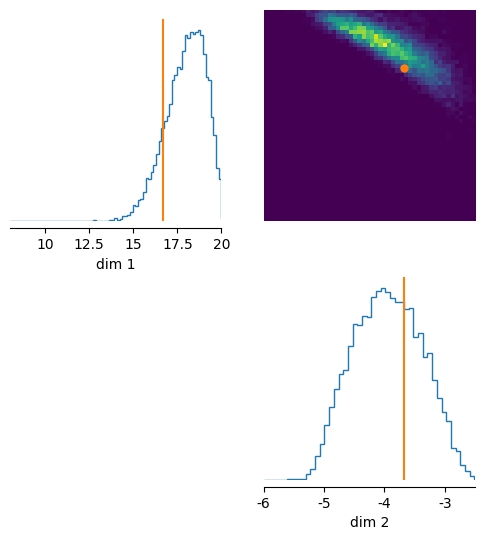

In [64]:
i = 4
samples = posterior.sample((10000,), x=GT[i,2:].astype('float32'))
limits = [[8, 20]]+[[-6,-2.5]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT[i:i+1,:3]
)

In [74]:
X = []
SEEDS = [f"{int(seed)}" for seed in np.arange(2000)]
for seed in SEEDS:
    g = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['gs'].squeeze()[0]
    js = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['js'].squeeze()[:,0]
    etas = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['etas'].squeeze()[:,0]
    ps = np.load(f"{results_path}/mlp/params/params_mlp_qif_internal_homogeneous_seed{seed}_sub-003.npz")['ps'].squeeze()[:,0]
    feats = np.load(f"{results_path}/mlp/feats/feat_mlp_qif_internal_seed{seed}.npz")['bold'][:,6:]
    vbi_fc = feats[:,:26]
    vbi_fc = np.delete(vbi_fc, 19, 1)
    vbi_fcd = feats[:,27:27+26]
    vbi_fcd = np.delete(vbi_fcd, 19, 1)
    # vbi_fcd = np.delete(vbi_fcd, 18, 1)
    zero_cross = feats[:,-500:-400]
    X.append(np.c_[js, etas, ps, vbi_fc, vbi_fcd, zero_cross.mean(axis=1)])

In [76]:
X = np.vstack(X)
to_del = np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[0][np.unique(np.argwhere(np.isnan(X))[:,1], return_counts=True)[1]==X.shape[0]]
print(to_del)
X = np.delete(X, to_del, 1)
print(X.shape)
X = np.delete(X, np.unique(np.argwhere(np.isnan(X))[:,0]), 0) # delete datapoints where at least one feature is nan
print(X.shape)
np.random.seed(42)
to_remove = np.random.choice(X.shape[0], 500, replace=False)
GT = X[to_remove]
GT.shape, X.shape
X = np.delete(X, to_remove, 0)
np.random.seed(0)
np.random.shuffle(X)
X.shape
np.save('artifacts/gt_params_mlp_qif.npy', GT)
prior = MultipleIndependent(
    [Uniform(low=torch.tensor([8.]), high=torch.tensor([20.]))]*1+[Uniform(low=torch.tensor([-6.]), high=torch.tensor([-2.5]))]+[Uniform(low=torch.tensor([.6]), high=torch.tensor([1.]))]
)
x = torch.from_numpy(X[:,3:].astype('float32'))
theta = torch.from_numpy(X[:,:3].astype('float32'))

[]
(160000, 54)
(160000, 54)


In [77]:
maf = posterior_nn(
    model="maf", z_score_theta='independent', z_score_x='independent', embedding_net=nn.Identity(), num_transforms=10, hidden_features=50
)
inference = NPE(prior=prior, density_estimator=maf, device='cpu')
inference.append_simulations(theta, x)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 122 epochs.

In [78]:
with open('artifacts/posterior_mlp_qif_sims.pkl', 'wb') as f:
    pickle.dump(posterior, f)

10569it [00:00, 60696.71it/s]                          


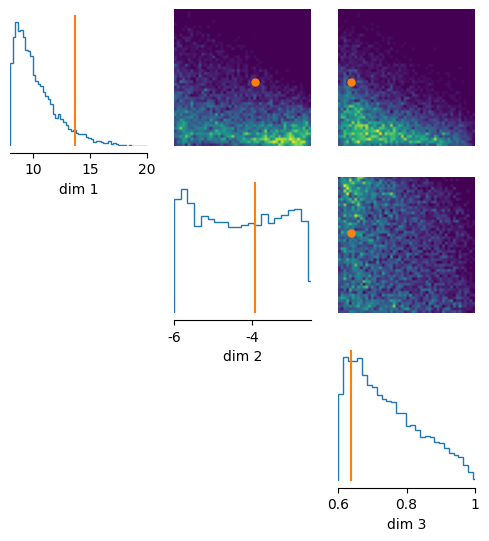

In [79]:
i = 24
samples = posterior.sample((10000,), x=GT[i,3:].astype('float32'))
limits = [[8., 20.]]+[[-6,-2.5]]+[[.6,1.]]
_ = pairplot(
    samples, figsize=(6, 6),
    limits=limits,
    points=GT[i:i+1,:3]
)